# **Weather Data Analysis**

**Data Exploration**

Load Data from github

In [ ]:
#url = 'https://raw.githubusercontent.com/khunsa123/SM-Big-Data-Analytics/main/weather_hourly_darksky.csv'
#data = pd.read_csv(url)

Load Data from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sn
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import datetime

In [ ]:
data = pd.read_csv("/content/gdrive/MyDrive/SMDATA/weather_hourly_darksky.csv")

In [ ]:
data.head()

,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy


**Creating a copy of data **

In [ ]:
dfcopy = data.copy()

In [ ]:
dfcopy.head()

,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy


In [ ]:
print(dfcopy.describe())

         visibility   windBearing   temperature      dewPoint      pressure  \
count  21165.000000  21165.000000  21165.000000  21165.000000  21152.000000   
mean      11.166485    195.685897     10.471486      6.530501   1014.125153   
std        3.099337     90.629453      5.781904      5.041965     11.388337   
min        0.180000      0.000000     -5.640000     -9.980000    975.740000   
25%       10.120000    121.000000      6.470000      2.820000   1007.430000   
50%       12.260000    217.000000      9.930000      6.570000   1014.780000   
75%       13.080000    256.000000     14.310000     10.330000   1022.050000   
max       16.090000    359.000000     32.400000     19.880000   1043.320000   

       apparentTemperature     windSpeed      humidity  
count         21165.000000  21165.000000  21165.000000  
mean              9.230338      3.905215      0.781829  
std               6.940919      2.026854      0.140369  
min              -8.880000      0.040000      0.230000  
25%

In [ ]:
print('Dataset shape: ', data.shape)

Dataset shape:  (21165, 12)


# **Data Preprocessing**

**Renaming the time coloumn**

In [ ]:
dfcopy = dfcopy.rename(columns={"time": "date"})

**Converting it to the appropriate date format**

In [ ]:
dfcopy['date'] = pd.to_datetime(dfcopy['date'])

**Indexing the date and droping the column**

In [ ]:
dfcopy.set_index('date',drop=True, inplace=True)

**Resampling on a monthly bases**

In [ ]:
dfcopy = dfcopy.resample('M').mean()

In [ ]:
dfcopy.head()

,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,humidity
date,,,,,,,,
2011-11-30,8.215986,162.320833,10.595708,8.669917,1017.059139,10.004958,3.530500,0.883556
2011-12-31,12.519261,243.370968,7.087527,4.142728,1011.889664,4.624368,5.076720,0.819892
2012-01-31,11.484866,215.395161,6.776707,3.705578,1021.070349,4.701922,4.373333,0.813750
2012-02-29,10.541695,210.794540,4.868534,1.270101,1029.737687,2.829899,3.442011,0.783851
2012-03-31,9.320403,191.595430,9.307433,4.746989,1027.735833,8.151828,2.933952,0.752702


**Checking for null values**

In [ ]:
print(dfcopy.isnull().sum().sum())

0


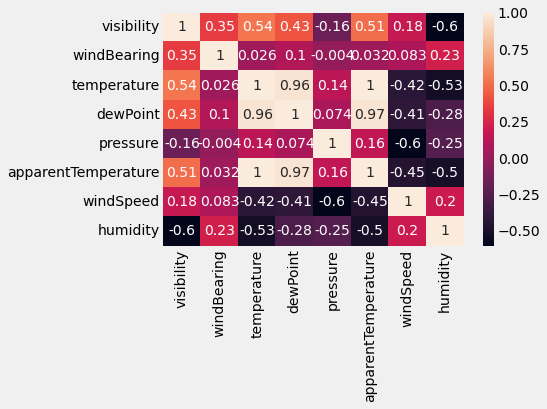

In [ ]:
sn.heatmap(dfcopy.corr(), annot=True)
plt.show()

In [ ]:
print(dfcopy.corr())

                     visibility  windBearing  temperature  dewPoint  pressure  \
visibility             1.000000     0.346500     0.541131  0.428593 -0.160939   
windBearing            0.346500     1.000000     0.026448  0.102110 -0.004003   
temperature            0.541131     0.026448     1.000000  0.964647  0.136635   
dewPoint               0.428593     0.102110     0.964647  1.000000  0.073816   
pressure              -0.160939    -0.004003     0.136635  0.073816  1.000000   
apparentTemperature    0.508028     0.031837     0.997578  0.968422  0.158837   
windSpeed              0.184484     0.083362    -0.423773 -0.408639 -0.603100   
humidity              -0.598620     0.227390    -0.525258 -0.283148 -0.248628   

                     apparentTemperature  windSpeed  humidity  
visibility                      0.508028   0.184484 -0.598620  
windBearing                     0.031837   0.083362  0.227390  
temperature                     0.997578  -0.423773 -0.525258  
dewPoint      

**Visibility**

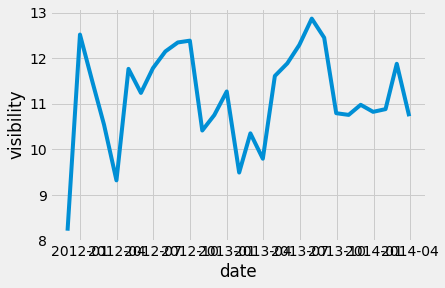

In [ ]:
sn.lineplot(data=dfcopy, x="date", y="visibility")

**windBearing**

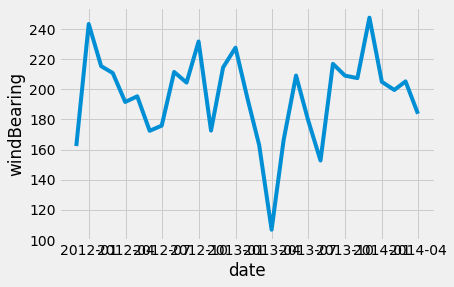

In [ ]:
sn.lineplot(data=dfcopy, x="date", y="windBearing")

**temperature**

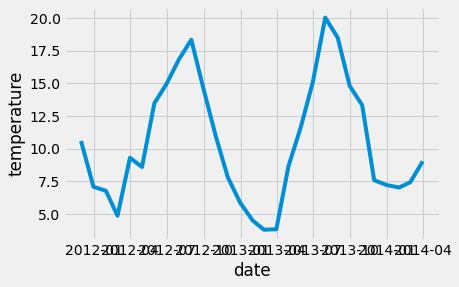

In [ ]:
sn.lineplot(data=dfcopy, x="date", y="temperature")

**dewPoint**

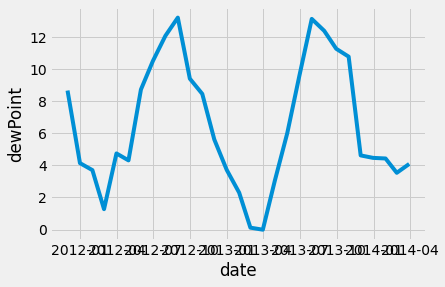

In [ ]:
sn.lineplot(data=dfcopy, x="date", y="dewPoint")

**pressure**

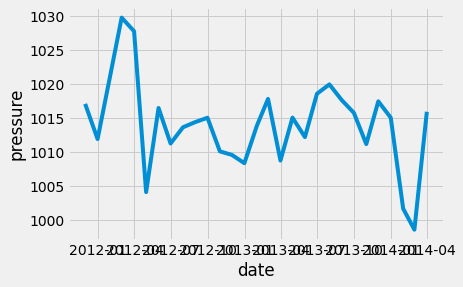

In [ ]:
sn.lineplot(data=dfcopy, x="date", y="pressure")

**apparentTemperature**

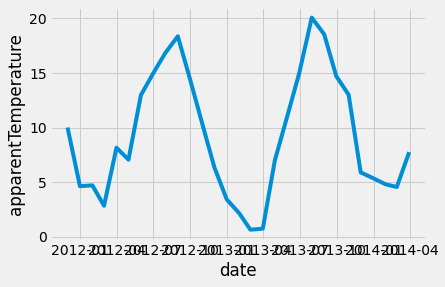

In [ ]:
sn.lineplot(data=dfcopy, x="date", y="apparentTemperature")

**windSpeed**

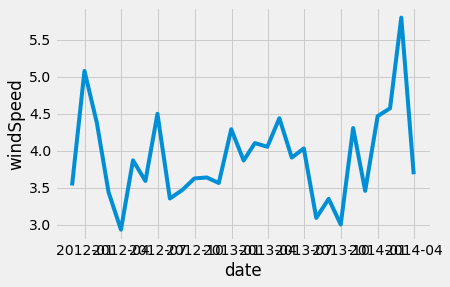

In [ ]:

sn.lineplot(data=dfcopy, x="date", y="windSpeed")

**humidity**

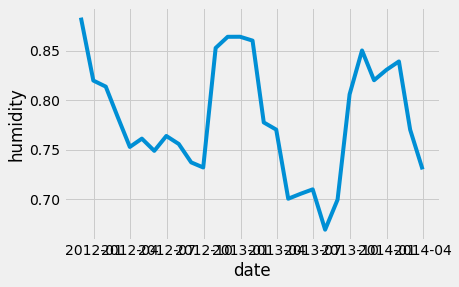

In [ ]:
sn.lineplot(data=dfcopy, x="date", y="humidity")

# **Daily Consumptions**

Checking Daily Consumption for 3 days
22, 23 and 24 November 2013

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import datetime, time

In [ ]:
import os
for dirname, _, filenames in os.walk('/content/gdrive'):
    for filename in filenames:
        os.path.join(dirname, filename)
        
df2 = pd.read_csv('/content/gdrive/MyDrive/SMDATA/halfhourly_dataset/block_0.csv')        
householdInfos = pd.read_csv('/content/gdrive/MyDrive/SMDATA/halfhourly_dataset/block_0.csv')        

print(df2.head())
print(df2.columns)

household = "MAC000002"

df2 = df2[df2["LCLid"] == household ]

"""
for i in range(df.shape[0]):
    df2.loc[i,'datetime'] = datetime.datetime.strptime(df2.loc[i,'tstp'].replace('.0000000', ''), '%Y-%m-%d %H:%M:%S')
    df2.loc[i,'date'] = df2.loc[i,'datetime'].date()
    df2.loc[i,'month'] = df2.loc[i,'datetime'].strftime("%B")
    df2.loc[i,'day_of_month'] = df2.loc[i,'datetime'].strftime("%d")
    df2.loc[i,'time'] = df2.loc[i,'datetime'].strftime('%X')
    df2.loc[i,'weekday'] = df2.loc[i,'datetime'].strftime('%A')
"""
def myfunc(df2):
    for i in range(df2.shape[0]):
#    for i in range(40):
        df2.loc[i,'datetime'] = datetime.datetime.strptime(df2.loc[i,'tstp'].replace('.0000000', ''), '%Y-%m-%d %H:%M:%S')
        df2.loc[i,'month'] = df2.loc[i,'datetime'].strftime("%B")
        df2.loc[i,'day_of_month'] = int(df2.loc[i,'datetime'].strftime("%d"))
        df2.loc[i,'time'] = df2.loc[i,'datetime'].strftime('%X')
        df2.loc[i,'year'] = df2.loc[i,'datetime'].strftime("%Y")

myfunc(df2)

       LCLid                         tstp energy(kWh/hh)
0  MAC000002  2012-10-12 00:30:00.0000000             0 
1  MAC000002  2012-10-12 01:00:00.0000000             0 
2  MAC000002  2012-10-12 01:30:00.0000000             0 
3  MAC000002  2012-10-12 02:00:00.0000000             0 
4  MAC000002  2012-10-12 02:30:00.0000000             0 
Index(['LCLid', 'tstp', 'energy(kWh/hh)'], dtype='object')


/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:1684: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = infer_fill_value(value)
/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


In [ ]:
def getPlotOfTheDay(year,month,day,df2):
    print(df2[(df2['year']==year)&(df2['month']==month) & (df2['day_of_month'] ==float(day) )])
    return df2[(df2['year']==year)&(df2['month']==month) & (df2['day_of_month'] ==float(day) )]


getPlotOfTheDay("2012","November",20,df2)

          LCLid                         tstp energy(kWh/hh)  \
1821  MAC000002  2012-11-20 00:00:00.0000000         0.258    
1822  MAC000002  2012-11-20 00:30:00.0000000         0.198    
1823  MAC000002  2012-11-20 01:00:00.0000000         0.265    
1824  MAC000002  2012-11-20 01:30:00.0000000         0.228    
1825  MAC000002  2012-11-20 02:00:00.0000000          0.25    
1826  MAC000002  2012-11-20 02:30:00.0000000         0.247    
1827  MAC000002  2012-11-20 03:00:00.0000000         0.213    
1828  MAC000002  2012-11-20 03:30:00.0000000         0.135    
1829  MAC000002  2012-11-20 04:00:00.0000000         0.082    
1830  MAC000002  2012-11-20 04:30:00.0000000         0.196    
1831  MAC000002  2012-11-20 05:00:00.0000000         0.151    
1832  MAC000002  2012-11-20 05:30:00.0000000         0.125    
1833  MAC000002  2012-11-20 06:00:00.0000000         0.091    
1834  MAC000002  2012-11-20 06:30:00.0000000         0.127    
1835  MAC000002  2012-11-20 07:00:00.0000000         0.

,LCLid,tstp,energy(kWh/hh),datetime,month,day_of_month,time,year
1821,MAC000002,2012-11-20 00:00:00.0000000,0.258,2012-11-20 00:00:00,November,20.0,00:00:00,2012
1822,MAC000002,2012-11-20 00:30:00.0000000,0.198,2012-11-20 00:30:00,November,20.0,00:30:00,2012
1823,MAC000002,2012-11-20 01:00:00.0000000,0.265,2012-11-20 01:00:00,November,20.0,01:00:00,2012
1824,MAC000002,2012-11-20 01:30:00.0000000,0.228,2012-11-20 01:30:00,November,20.0,01:30:00,2012
1825,MAC000002,2012-11-20 02:00:00.0000000,0.25,2012-11-20 02:00:00,November,20.0,02:00:00,2012
1826,MAC000002,2012-11-20 02:30:00.0000000,0.247,2012-11-20 02:30:00,November,20.0,02:30:00,2012
1827,MAC000002,2012-11-20 03:00:00.0000000,0.213,2012-11-20 03:00:00,November,20.0,03:00:00,2012
1828,MAC000002,2012-11-20 03:30:00.0000000,0.135,2012-11-20 03:30:00,November,20.0,03:30:00,2012
1829,MAC000002,2012-11-20 04:00:00.0000000,0.082,2012-11-20 04:00:00,November,20.0,04:00:00,2012
1830,MAC000002,2012-11-20 04:30:00.0000000,0.196,2012-11-20 04:30:00,November,20.0,04:30:00,2012


In [ ]:
df2 = df2[df2["energy(kWh/hh)"] != "Null"]

df2.loc[:,"energy(kWh/hh)"] = df2["energy(kWh/hh)"].astype("float64")

/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


           LCLid                         tstp  energy(kWh/hh)  \
19437  MAC000002  2013-11-22 00:00:00.0000000           0.224   
19438  MAC000002  2013-11-22 00:30:00.0000000           0.238   
19439  MAC000002  2013-11-22 01:00:00.0000000           0.233   
19440  MAC000002  2013-11-22 01:30:00.0000000           0.116   
19441  MAC000002  2013-11-22 02:00:00.0000000           0.122   
19442  MAC000002  2013-11-22 02:30:00.0000000           0.076   
19443  MAC000002  2013-11-22 03:00:00.0000000           0.120   
19444  MAC000002  2013-11-22 03:30:00.0000000           0.075   
19445  MAC000002  2013-11-22 04:00:00.0000000           0.119   
19446  MAC000002  2013-11-22 04:30:00.0000000           0.080   
19447  MAC000002  2013-11-22 05:00:00.0000000           0.113   
19448  MAC000002  2013-11-22 05:30:00.0000000           0.091   
19449  MAC000002  2013-11-22 06:00:00.0000000           0.099   
19450  MAC000002  2013-11-22 06:30:00.0000000           0.102   
19451  MAC000002  2013-11

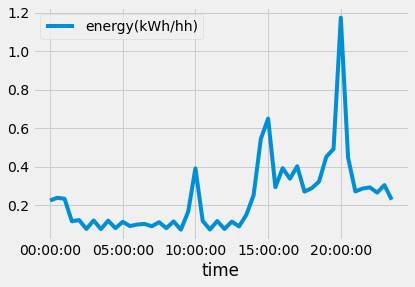

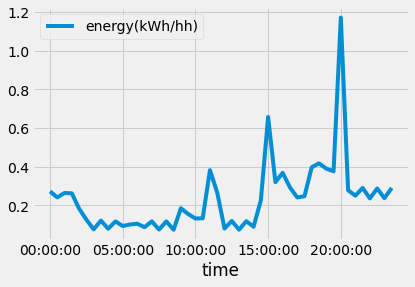

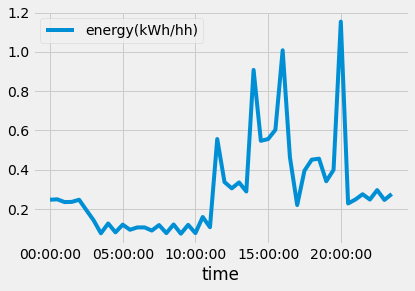

In [ ]:
for i in [22,23,24]:
    day = getPlotOfTheDay("2013","November",i,df2)
    day.plot(y="energy(kWh/hh)",x="time")